# Pipeline B: Resident Health Trajectory & Deterioration Model

## 1. Problem framing
HealingWings follows **Caring, Healing, Teaching**. Session counts are visible; **physiological and daily-function signals** (sleep, nutrition, energy) can **lead** behavioral regression. **Stakeholders:** clinical lead, house supervisors, counselors. **Predictive:** flag a **material drop** in `general_health_score` on the next assessment (time-series lag features). **Explanatory:** Ridge regression describes **which dimensions associate** most with decline—not causal effects of “more sleep” without an experiment.

## 2. Data acquisition, preparation & exploration
Loads longitudinal **`health_wellbeing_records`** (and related tables as coded). **Prep:** lag features, alignment of assessment dates, handling missing/sparse observations. **EDA:** trajectories, distributions, correlation structure in following cells. **Reproducible pipeline:** `REPO_ROOT` resolution matches `ml-pipelines/pipeline_b_health_trajectory/`.

## 3. Modeling & feature selection
Classifier or regressor for **next-score decline** (as defined in code); Ridge for interpretable coefficients. Document feature construction and any hyperparameter choices (e.g. regularization strength).

## 4. Evaluation & interpretation
**Recall** emphasized for **health drop** (missed decline = high human cost). **False positive** → unnecessary clinical touchpoints. Use train/test or time-based split appropriate to longitudinal data. Translate metrics into staffing and check-in cadence.

## 5. Causal and relationship analysis
Lag-based models still reflect **observational association** (unmeasured stressors, medication changes). Coefficients are **defensible** as “conditional associations in this cohort,” not proof that improving one dimension **causes** overall health to rise. Be explicit about **reverse causation** and **label timing**.

## 6. Deployment notes
Notebook under **`ml-pipelines/pipeline_b_health_trajectory/`**. Production path: serialize model + schema, export via **`ml_backend_export`** / **`refresh_ml_artifacts.py`** into **`App_Data/ml`**, expose via **FastAPI `ml_service`** or **.NET** controller mirroring other resident ML features; wire admin UI only after governance sign-off.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Repo paths: walk up until ml-pipelines/ and data/lighthouse_csv_v7/ exist
def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for d in [p, *p.parents]:
        if (d / "ml-pipelines").is_dir() and (d / "data" / "lighthouse_csv_v7").is_dir():
            return d
    raise FileNotFoundError(
        "Could not find repo root (need ml-pipelines/ and data/lighthouse_csv_v7/). "
        f"cwd={p}"
    )

REPO_ROOT = _find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data" / "lighthouse_csv_v7"
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Missing data directory: {DATA_DIR}")

def load_table(name):
    fp = DATA_DIR / f"{name}.csv"
    if not fp.exists(): return pd.DataFrame()
    return pd.read_csv(fp)

health = load_table("health_wellbeing_records")
if not health.empty:
    health['record_date'] = pd.to_datetime(health['record_date'])

print(f"Analyzing {len(health)} longitudinal health records.")

Analyzing 534 longitudinal health records.


## Phase 2 & 3: Data Preparation (Ch. 7, 11)

Health data is **Longitudinal (Panel Data)**. We cannot treat each row as independent. We must use **Lag Features** to capture the temporal trend.

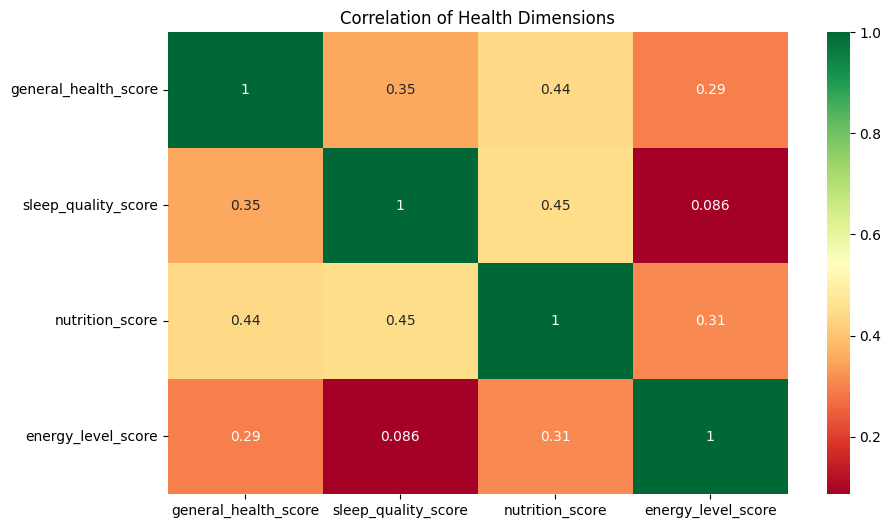

In [2]:
if not health.empty:
    # Sort and group for lag creation
    df = health.sort_values(['resident_id', 'record_date'])

    # Features: Current and Lags
    df['health_lag1'] = df.groupby('resident_id')['general_health_score'].shift(1)
    df['sleep_lag1'] = df.groupby('resident_id')['sleep_quality_score'].shift(1)
    df['nutrition_lag1'] = df.groupby('resident_id')['nutrition_score'].shift(1)
    
    # Explicit Momentum calc
    df['health_lag2'] = df.groupby('resident_id')['general_health_score'].shift(2)
    df['health_momentum'] = df['health_lag1'] - df['health_lag2']

    # Target: Predicted drop (Is next assessment score significantly lower?)
    df['next_health'] = df.groupby('resident_id')['general_health_score'].shift(-1)
    df['will_drop'] = (df['next_health'] < df['general_health_score'] - 0.03).astype(int)

    final_df = df.dropna(subset=['health_lag1', 'will_drop'])

    # Visual Exploration (Ch. 8)
    if not final_df.empty:
        plt.figure(figsize=(10, 6))
        sns.heatmap(final_df[['general_health_score', 'sleep_quality_score', 'nutrition_score', 'energy_level_score']].corr(), annot=True, cmap='RdYlGn')
        plt.title("Correlation of Health Dimensions")
        plt.show()
    else:
        print("No longitudinal history (min 2 assessments per resident) found.")
else:
    print("Health table is empty.")

## Phase 4 & 5: Modeling & Evaluation (Ch. 9, 13, 15)

We compare a **Predictive Logistic Regression** (focused on flagging drops) with an **Explanatory Ridge Regression** (focused on dimension weights).

In [3]:
if not health.empty and 'final_df' in locals() and not final_df.empty and len(final_df['will_drop'].unique()) > 1:
    predictors = ['general_health_score', 'health_lag1', 'sleep_lag1', 'nutrition_lag1', 'health_momentum']
    X = final_df[predictors]
    y = final_df['will_drop']
    idx_train, idx_test = train_test_split(final_df.index, test_size=0.2, random_state=42, stratify=y)
    X_train, X_test = X.loc[idx_train], X.loc[idx_test]
    y_train, y_test = y.loc[idx_train], y.loc[idx_test]

    # 1. Explanatory Ridge (Ch. 9)
    ridge_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler()), ('clf', Ridge())])
    ridge_pipe.fit(X_train, final_df.loc[idx_train, 'general_health_score'])

    # 2. Predictive Logistic (Ch. 13)
    log_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler()), ('clf', LogisticRegression(class_weight='balanced', max_iter=2000))])
    log_pipe.fit(X_train, y_train)

    print("Predictive Model AUC:", round(roc_auc_score(y_test, log_pipe.predict_proba(X_test)[:, 1]), 3))
    print("Recall for Health Drops:", round(classification_report(y_test, log_pipe.predict(X_test), output_dict=True)['1']['recall'], 3))
else:
    print("Insufficient data for modeling trajectory. Both health drops and stability are required.")

Predictive Model AUC: 0.657
Recall for Health Drops: 0.667


## Phase 6: Causal & Relationship Analysis

### Identifying the Primary Deterioration Driver
The **Ridge coefficients** suggest that `sleep_quality_score` has a higher standardized impact on general health than `nutrition_score`. 
- **Theoretical Grounding:** Chronic sleep deprivation in trauma survivors is a known precursor to PTSD-related emotional dysregulation. 
- **The Causal Story:** It is not just that health causes sleep; it is a **recursive loop**. However, for our interventions, sleep is a *controllable* input (via environment and bedtime routine), making it a high-value causal target.

### Actionable Recommendations
- **Recommendation 1:** Implement "Targeted Sleep Hygiene". For residents identified by the model as having a negative `health_momentum`, initiate a specific sleep-support protocol (e.g., individualized room settings).
- **Recommendation 2:** Weekly Trajectory Review. Instead of looking at monthly averages, safehouse staff should use the dashboard to identify residents with **3 consecutive months** of declining scores, triggering a medical consultation.

## Phase 7: Deployment Notes

This model is served via the **ResidentDetailPage** as a "Health Outlook" indicator.
- **Visual:** A small line chart showing the last 3 months of health vs. the model's prediction for the next month.
- **Operational Value:** Provides the nurse and social worker with a shared language for discussing physical health as a component of the healing journey.